# Phase 4: Published baselines and the label budget curve

CPU only. Attach the Phase 1 notebook output. Same setup as Phase 3.

In [3]:
import glob, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.stats import beta

p=[h for h in glob.glob("/kaggle/input/**/*.npz",recursive=True) if h.endswith("logits.npz")][0]
d=np.load(p); SEEDS=[0,1,2]
CORR=["gaussian_noise","shot_noise","impulse_noise","defocus_blur","glass_blur",
      "motion_blur","zoom_blur","snow","frost","fog","brightness","contrast",
      "elastic_transform","pixelate","jpeg_compression"]
CELLS=[("test",0)]+[(c_,s) for s in range(1,6) for c_ in CORR]
TG=0.05; TOL=1e-9

def softmax(z,T=1.0):
    z=z.astype(np.float64)/T; z-=z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def nll(p,y): return -np.log(np.clip(p[np.arange(len(y)),y],1e-12,None)).mean()
def ep(mats,T): return np.mean([softmax(m,T) for m in mats],0)

TE=minimize_scalar(lambda t: nll(ep([d[f"val_{s}"] for s in SEEDS],t),d["y_val"]),
                   bounds=(.5,10),method="bounded").x
PVAL=ep([d[f"val_{s}"] for s in SEEDS],TE); YVAL=d["y_val"]
P={}
for k,s in CELLS:
    key="test" if k=="test" else f"{k}_{s}"
    P[(k,s)]=(ep([d[f"{key}_{sd}"] for sd in SEEDS],TE),
              d["y_test"] if k=="test" else d["y_corr"])
print(f"T_ens={TE:.3f}  cells={len(P)}")

T_ens=1.242  cells=76


## 1. Threshold selectors

In [4]:
def risk_cov(pr,y,thr):
    conf,pred=pr.max(1),pr.argmax(1); a=conf>=thr
    if a.sum()==0: return np.nan,0.0
    return 1-(pred[a]==y[a]).mean(), a.mean()

def _pick(conf, est, target):
    """est[i] = estimated risk if we accept the i+1 most confident points."""
    ok=np.where(est<=target+TOL)[0]
    return 1.0 if len(ok)==0 else np.sort(conf)[::-1][ok[-1]]

def thr_oracle(pr,y,target):
    conf=pr.max(1); o=np.argsort(-conf)
    est=1-np.cumsum(pr.argmax(1)[o]==y[o])/np.arange(1,len(o)+1)
    return _pick(conf,est,target)

def thr_clean_transfer(target):            # current practice
    return thr_oracle(PVAL,YVAL,target)

def thr_meanconf(pr,target):               # Phase 3 rule
    conf=pr.max(1); o=np.argsort(-conf)
    return _pick(conf,np.cumsum(1-conf[o])/np.arange(1,len(o)+1),target)

# --- ATC (Garg et al. 2022): calibrate a score cutoff on val so that the
#     fraction below it equals val error, then reuse that cutoff under shift.
def _atc_cut(score_val, correct_val):
    err=1-correct_val.mean()
    return np.quantile(score_val, err)

NEGENT=lambda pr: (pr*np.log(np.clip(pr,1e-12,None))).sum(1)   # higher = more confident
S_VAL_MC = PVAL.max(1); S_VAL_NE = NEGENT(PVAL)
CORR_VAL = PVAL.argmax(1)==YVAL
CUT_MC=_atc_cut(S_VAL_MC,CORR_VAL); CUT_NE=_atc_cut(S_VAL_NE,CORR_VAL)

def thr_atc(pr,target,mode="MC"):
    conf=pr.max(1); s=conf if mode=="MC" else NEGENT(pr)
    cut=CUT_MC if mode=="MC" else CUT_NE
    o=np.argsort(-conf)
    est=np.cumsum(s[o]<cut)/np.arange(1,len(o)+1)   # ATC error estimate on accepted set
    return _pick(conf,est,target)

# --- DoC (Guillory et al. 2021): shift the val error by the drop in mean confidence.
def thr_doc(pr,target):
    conf=pr.max(1); o=np.argsort(-conf)
    cv=np.sort(PVAL.max(1))[::-1]; corr=PVAL.argmax(1)[np.argsort(-PVAL.max(1))]==YVAL[np.argsort(-PVAL.max(1))]
    n=min(len(o),len(cv))
    err_val=1-np.cumsum(corr)/np.arange(1,len(cv)+1)
    gap=np.cumsum(cv)/np.arange(1,len(cv)+1)
    f=lambda a,m: np.interp(np.linspace(0,1,len(o)), np.linspace(0,1,len(a)), a)
    est=f(err_val,n)+(f(gap,n)-np.cumsum(conf[o])/np.arange(1,len(o)+1))
    return _pick(conf,est,target)
print("ok")

ok


## 2. Baseline comparison

Realised risk under a 5% target, averaged over the 15 corruptions at each
severity. Oracle uses labels on the shifted set and is the achievable floor.

In [5]:
METHODS={"clean-transfer": lambda pr,y: thr_clean_transfer(TG),
         "mean-conf":     lambda pr,y: thr_meanconf(pr,TG),
         "ATC-MC":        lambda pr,y: thr_atc(pr,TG,"MC"),
         "ATC-NE":        lambda pr,y: thr_atc(pr,TG,"NE"),
         "DoC":           lambda pr,y: thr_doc(pr,TG),
         "oracle":        lambda pr,y: thr_oracle(pr,y,TG)}

res={}
for name,fn in METHODS.items():
    for sev in range(6):
        ks=[("test",0)] if sev==0 else [(c_,sev) for c_ in CORR]
        rc=[risk_cov(*P[k], fn(*P[k])) for k in ks]
        res[(name,sev)]=(np.nanmean([x[0] for x in rc]), np.mean([x[1] for x in rc]))

print("RISK (target 0.05)")
print(f"{'method':>15} "+" ".join(f"{s:>7}" for s in range(6)))
for n in METHODS: print(f"{n:>15} "+" ".join(f"{res[(n,s)][0]:>7.3f}" for s in range(6)))
print("\nCOVERAGE")
print(f"{'method':>15} "+" ".join(f"{s:>7}" for s in range(6)))
for n in METHODS: print(f"{n:>15} "+" ".join(f"{res[(n,s)][1]:>7.3f}" for s in range(6)))

RISK (target 0.05)
         method       0       1       2       3       4       5
 clean-transfer   0.047   0.118   0.172   0.233   0.306   0.423
      mean-conf   0.047   0.071   0.093   0.122   0.153   0.219
         ATC-MC   0.047   0.089   0.123   0.168   0.223   0.325
         ATC-NE   0.047   0.079   0.106   0.144   0.187   0.277
            DoC   0.047   0.072   0.094   0.123   0.154   0.220
         oracle   0.047   0.050   0.050   0.050   0.050   0.049

COVERAGE
         method       0       1       2       3       4       5
 clean-transfer   1.000   0.999   0.998   0.997   0.996   0.995
      mean-conf   1.000   0.890   0.809   0.728   0.632   0.491
         ATC-MC   1.000   0.931   0.884   0.833   0.771   0.679
         ATC-NE   1.000   0.909   0.842   0.775   0.697   0.575
            DoC   1.000   0.891   0.811   0.730   0.636   0.494
         oracle   1.000   0.833   0.696   0.584   0.458   0.264


## 3. Label budget curve

Give the selector n labelled points drawn from the shifted set, pick the
threshold on those with a Clopper-Pearson upper bound for finite sample slack,
then evaluate on the held out remainder. This is the practical question: how
many labels buy back the guarantee?

In [6]:
def cp_upper(k,n,alpha=0.1):
    return 1.0 if n==0 else (1.0 if k==n else beta.ppf(1-alpha,k+1,n-k))

def thr_sample(pr,y,idx,target,conservative=True):
    conf=pr[idx].max(1); corr=pr[idx].argmax(1)==y[idx]
    o=np.argsort(-conf); wrong=np.cumsum(~corr[o]); n=np.arange(1,len(o)+1)
    est=np.array([cp_upper(w,m) for w,m in zip(wrong,n)]) if conservative else wrong/n
    ok=np.where(est<=target+TOL)[0]
    return 1.0 if len(ok)==0 else conf[o][ok[-1]]

rng=np.random.default_rng(0); BUDGETS=[50,100,250,500,1000]; TRIALS=20
print(f"{'sev':>3} {'n':>5} {'risk':>7} {'cov':>7} {'viol':>6}   (target 0.05, CP 90%)")
for sev in [1,3,5]:
    for n in BUDGETS:
        rs,cs,vs=[],[],[]
        for c_ in CORR:
            pr,y=P[(c_,sev)]
            for _ in range(TRIALS):
                i=rng.permutation(len(y)); lab,ev=i[:n],i[n:]
                t=thr_sample(pr,y,lab,TG)
                r,cv=risk_cov(pr[ev],y[ev],t); rs.append(r); cs.append(cv); vs.append(r>TG+TOL)
        print(f"{sev:>3} {n:>5} {np.nanmean(rs):>7.3f} {np.mean(cs):>7.3f} {np.mean(vs)*100:>5.0f}%")

sev     n    risk     cov   viol   (target 0.05, CP 90%)
  1    50   0.028   0.195     2%
  1   100   0.020   0.593     3%
  1   250   0.030   0.738     6%
  1   500   0.036   0.774     6%
  1  1000   0.040   0.795     6%
  3    50   0.041   0.028     1%
  3   100   0.026   0.313     4%
  3   250   0.030   0.451     5%
  3   500   0.035   0.505     7%
  3  1000   0.039   0.531    10%
  5    50   0.050   0.009     1%
  5   100   0.038   0.082     3%
  5   250   0.030   0.135     3%
  5   500   0.034   0.196     6%
  5  1000   0.039   0.222    10%


/tmp/ipykernel_58/2720539994.py:11: RuntimeWarning: Mean of empty slice
  ys.append(np.nanmean(rs))


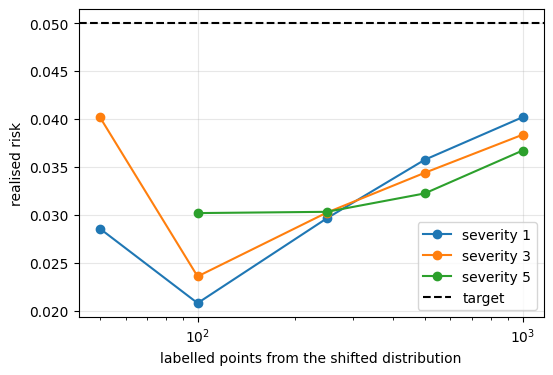

In [7]:
plt.figure(figsize=(6,4))
for sev in [1,3,5]:
    ys=[]
    for n in BUDGETS:
        rs=[]
        for c_ in CORR:
            pr,y=P[(c_,sev)]
            for _ in range(TRIALS):
                i=rng.permutation(len(y)); t=thr_sample(pr,y,i[:n],TG)
                rs.append(risk_cov(pr[i[n:]],y[i[n:]],t)[0])
        ys.append(np.nanmean(rs))
    plt.plot(BUDGETS,ys,"o-",label=f"severity {sev}")
plt.axhline(TG,ls="--",c="k",label="target"); plt.xscale("log")
plt.xlabel("labelled points from the shifted distribution")
plt.ylabel("realised risk"); plt.legend(); plt.grid(alpha=.3); plt.show()

## 4. For the writeup

The table in section 2 is your main result: five selectors, none of which hold
the guarantee, against an oracle that shows the guarantee is achievable. The
curve in section 3 is the constructive half, the label cost of a real fix.

Still missing before submission: a second architecture, and the four held out
CIFAR-10-C corruptions. Both need one more GPU commit of Phase 1.